## Grid Search Hyperparameter optimization

This case study is all about using grid searches to identify the optimal parameters for a machine learning algorithm. To complere this case study, you'll use the Pima Indian diabetes dataset from Kaggle and KNN. Follow along with the preprocessing steps of this case study.

Load the necessary packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

sns.set()

# set random seed to try make this exercise and solutions reproducible (NB: this is just for teaching purpose and not something you would do in real life)
random_seed_number = 42
np.random.seed(random_seed_number)

#### Load the diabetes data

In [2]:
diabetes_data = pd.read_csv('data/diabetes.csv')
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


**<font color='teal'> Start by reviewing the data info.</font>**

In [3]:
diabetes_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**<font color='teal'> Apply the describe function to the data.</font>**

In [4]:
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**<font color='teal'> Currently, the missing values in the dataset are represented as zeros. Replace the zero values in the following columns ['Glucose','BloodPressure','SkinThickness','Insulin','BMI'] with nan .</font>**

In [5]:
# Group the selected columns and create a variable medical_cols for better readability
medical_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

# View the sum of rows with zeros in medical_cols
diabetes_data[medical_cols].isin([0]).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [6]:
# Replace the zeros with nan and recheck 
diabetes_data[medical_cols] = diabetes_data[medical_cols].replace(0, np.nan)

diabetes_data[medical_cols].isin([0]).sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

**<font color='teal'> Plot histograms of each column. </font>**

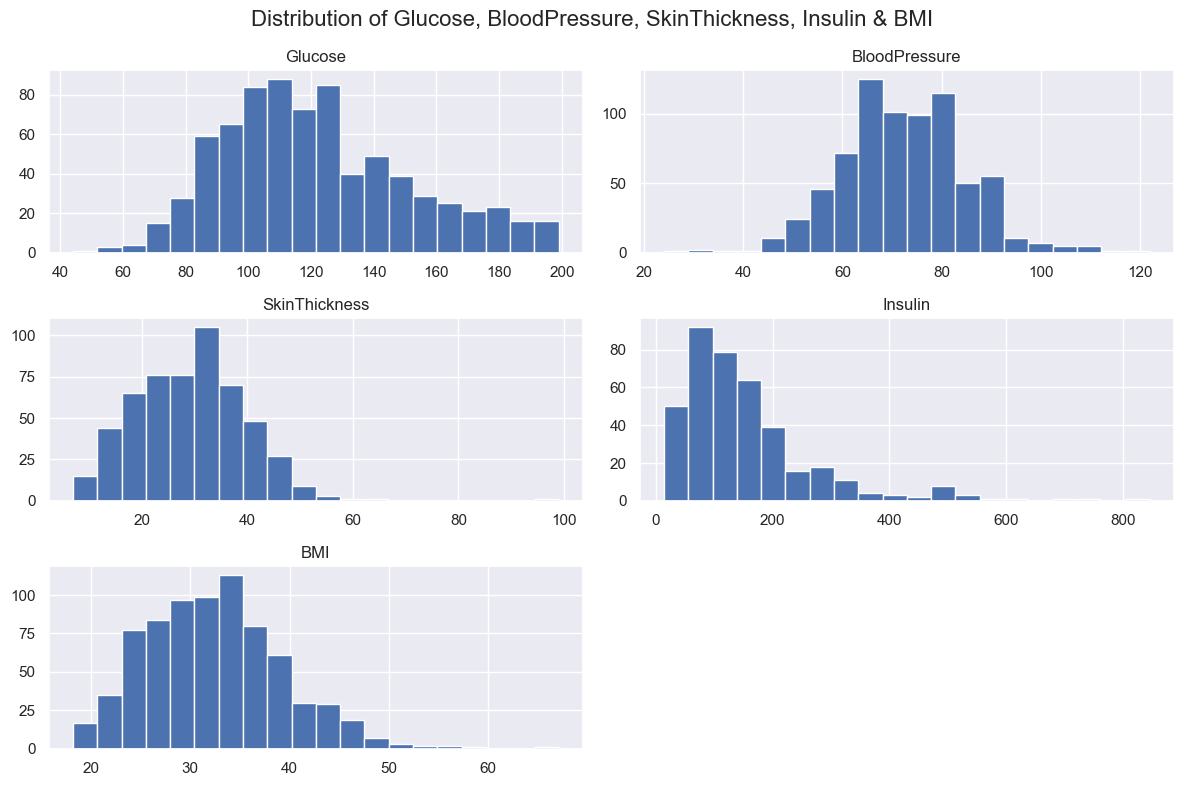

In [7]:
# Histogram plot for features in medical_cols
diabetes_data[medical_cols].hist(figsize=(12, 8), bins=20)

plt.suptitle("Distribution of Glucose, BloodPressure, SkinThickness, Insulin & BMI", fontsize=16)
plt.tight_layout()
plt.show()

#### Replace the zeros with mean and median values.

In [8]:
# Count of nans in our selected features
diabetes_data[medical_cols].isna().sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [9]:
# Replacing the zeros with mean and median values
diabetes_data['Glucose'] = diabetes_data['Glucose'].fillna(diabetes_data['Glucose'].mean())
diabetes_data['BloodPressure'] = diabetes_data['BloodPressure'].fillna(diabetes_data['BloodPressure'].mean())

diabetes_data['SkinThickness'] = diabetes_data['SkinThickness'].fillna(diabetes_data['SkinThickness'].median())
diabetes_data['Insulin'] = diabetes_data['Insulin'].fillna(diabetes_data['Insulin'].median())
diabetes_data['BMI'] = diabetes_data['BMI'].fillna(diabetes_data['BMI'].median())

In [10]:
# Count of nans in our selected features after replacement with aggregate functions
diabetes_data[medical_cols].isna().sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

**<font color='teal'> Plot histograms of each column after replacing nan. </font>**

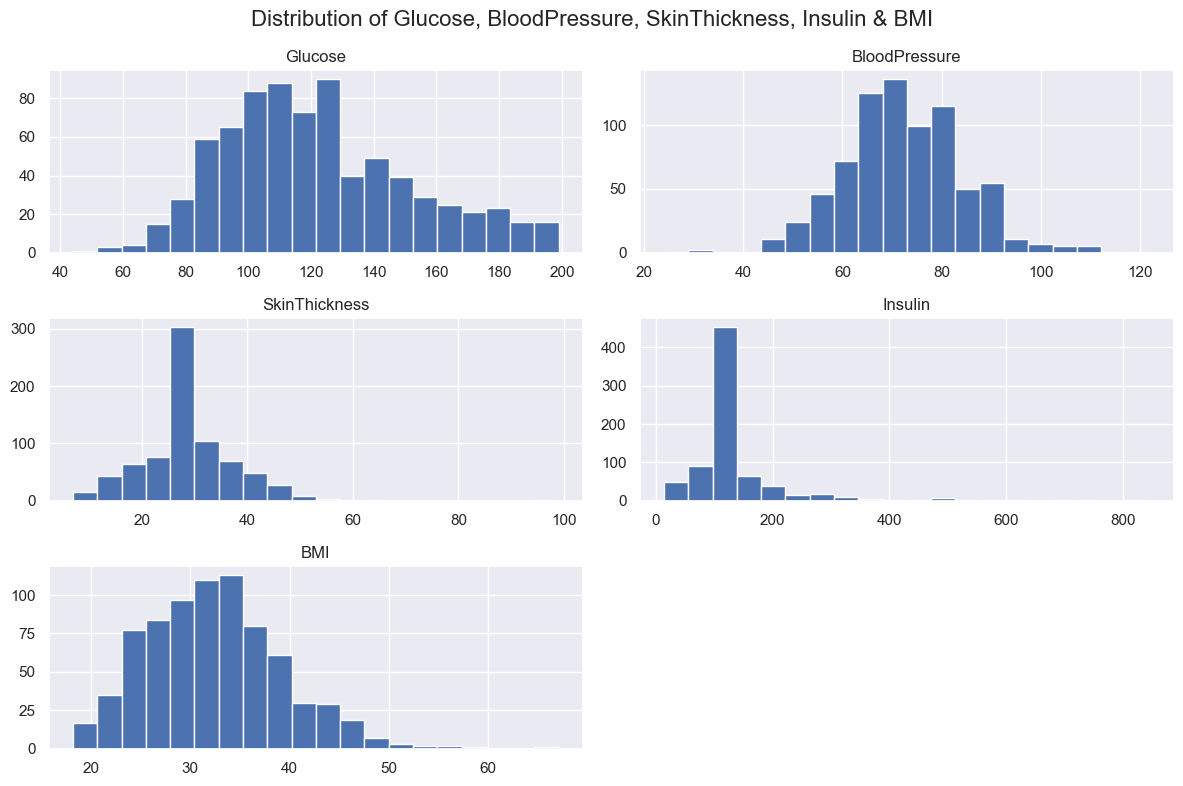

In [11]:
# Plot of histograms of each column after replacing nan
diabetes_data[medical_cols].hist(figsize=(12, 8), bins=20)

plt.suptitle("Distribution of Glucose, BloodPressure, SkinThickness, Insulin & BMI", fontsize=16)
plt.tight_layout()
plt.show()

#### Plot the correlation matrix heatmap

Correlation between various features


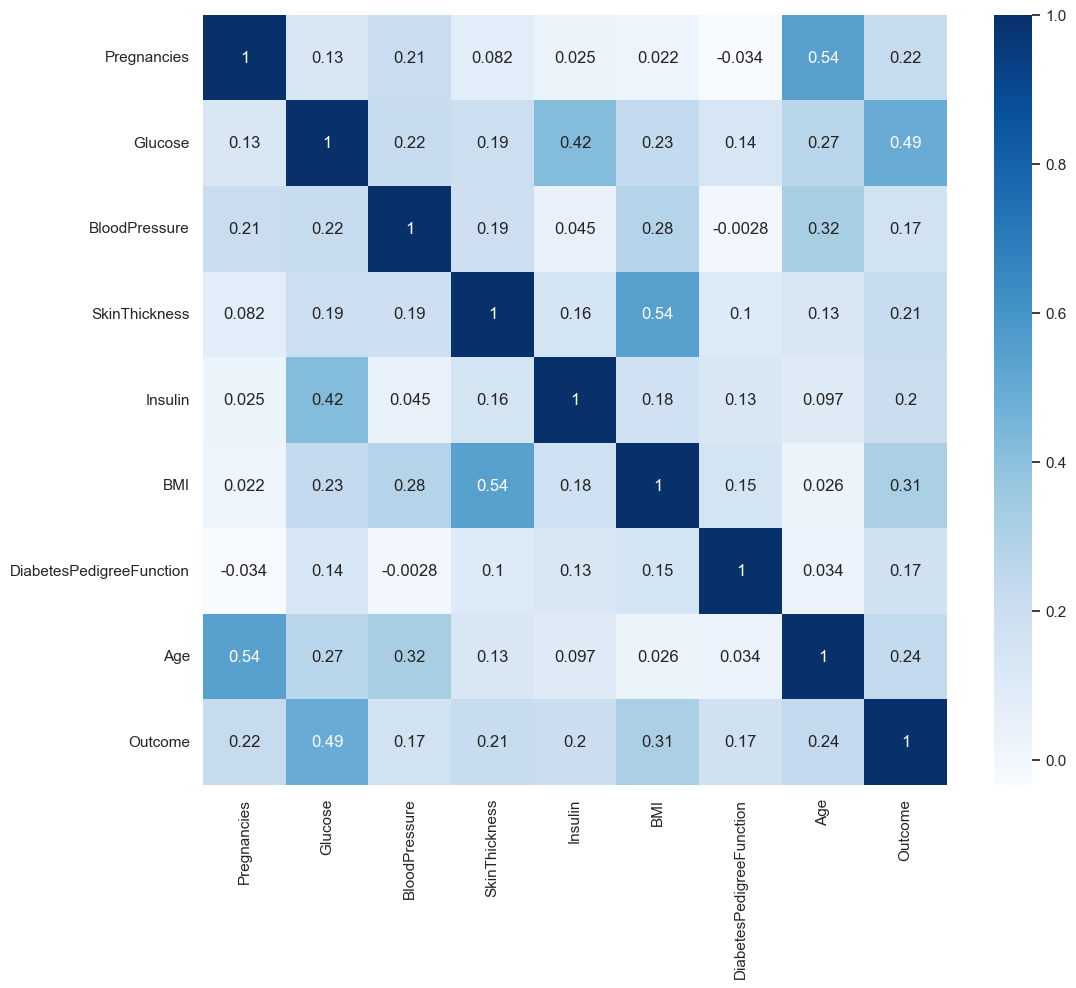

In [12]:
# Plot of the correlation matrix heatmap
plt.figure(figsize=(12,10))
print('Correlation between various features')
p=sns.heatmap(diabetes_data.corr(), annot=True,cmap ='Blues')

**<font color='teal'> Define the `y` variable as the `Outcome` column.</font>**

In [13]:
y= diabetes_data['Outcome'] #target
X = diabetes_data.drop(columns=['Outcome']) #features

**<font color='teal'> Create a 70/30 train and test split. </font>**

In [14]:
# Create a 70/30 train and test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

**<font color='teal'> Using Sklearn, standarize the magnitude of the features by scaling the values. </font>**

Note: Don't forget to fit() your scaler on X_train and then use that fitted scaler to transform() X_test. This is to avoid data leakage while you standardize your data.

In [15]:


# Standardize features
scaler = StandardScaler()

# Fit ONLY on training data X_train
X_train_scaled = scaler.fit_transform(X_train)

# Use same scaler on test data
X_test_scaled = scaler.transform(X_test)

In [16]:
# Shape of split dataset
print(X_train_scaled.shape, X_test_scaled.shape)

(537, 8) (231, 8)


#### Using a range of neighbor values of 1-10, apply the KNearestNeighbor classifier to classify the the data.

In [17]:
from sklearn.neighbors import KNeighborsClassifier


test_scores = []
train_scores = []

k_values = range(1, 10)
for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled ,y_train)
    
    train_scores.append(knn.score(X_train_scaled,y_train))
    test_scores.append(knn.score(X_test_scaled,y_test))

**<font color='teal'> Print the train and test scores for each iteration.</font>**

In [18]:
print(test_scores)
print(train_scores)

[0.7186147186147186, 0.7229437229437229, 0.7402597402597403, 0.7402597402597403, 0.7445887445887446, 0.7402597402597403, 0.7359307359307359, 0.7489177489177489, 0.7445887445887446]
[1.0, 0.8435754189944135, 0.8621973929236499, 0.8286778398510242, 0.8342644320297952, 0.8100558659217877, 0.8063314711359404, 0.8063314711359404, 0.8007448789571695]


**<font color='teal'> Identify the number of neighbors that resulted in the max score in the training dataset. </font>**

In [19]:
best_k = k_values[train_scores.index(max(train_scores))] #similar to: train_scores.index(best_score)
best_score = max(train_scores)

print("Best k:", best_k)
print("Best training score:", best_score)

Best k: 1
Best training score: 1.0


**<font color='teal'> Identify the number of neighbors that resulted in the max score in the testing dataset. </font>**

In [20]:
best_k = k_values[test_scores.index(max(test_scores))]
best_score = max(test_scores)

print("Best k:", best_k)
print("Best training score:", best_score)

Best k: 8
Best training score: 0.7489177489177489


Plot the train and test model performance by number of neighbors.

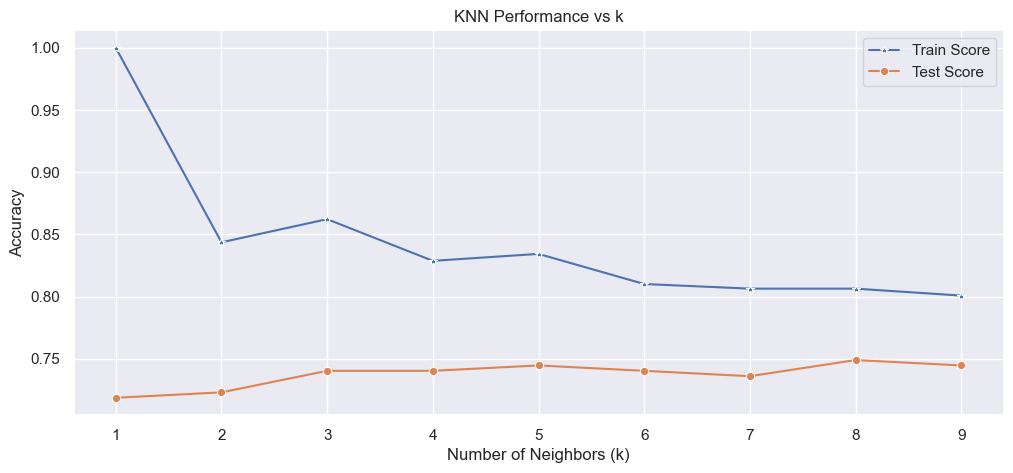

In [21]:
# Plot of the train and test model performance by number of neighbors.
plt.figure(figsize=(12,5))
p = sns.lineplot(x= range(1,10),y=train_scores,marker='*',label='Train Score')
p = sns.lineplot(x= range(1,10),y=test_scores,marker='o',label='Test Score')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN Performance vs k")
plt.legend()

**<font color='teal'> Fit and score the best number of neighbors based on the plot. </font>**

In [22]:
# Fit and score the best number of neighbors based on the plot.

# The optimal number of neighbors is k = 8, as it gives the highest test accuracy.
best_k = 8

# KNN model was fitted using k = 8 and evaluated on both training and test datasets.
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)

train_score = knn.score(X_train_scaled, y_train)
test_score = knn.score(X_test_scaled, y_test)

print("Best k:", best_k)
print("Train Accuracy:", train_score)
print("Test Accuracy:", test_score)

Best k: 8
Train Accuracy: 0.8063314711359404
Test Accuracy: 0.7489177489177489


In [23]:
from sklearn.metrics import confusion_matrix

y_pred = knn.predict(X_test_scaled)
pl = confusion_matrix(y_test,y_pred)

**<font color='teal'> Plot the confusion matrix for the model fit above. </font>**

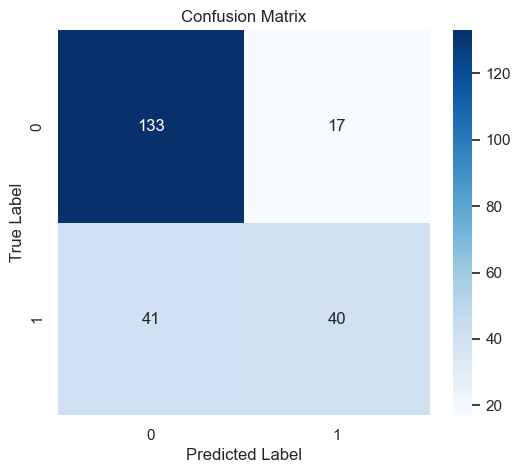

In [24]:
plt.figure(figsize=(6,5))

sns.heatmap(pl, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

**<font color='teal'> Print the classification report </font>**

In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.89      0.82       150
           1       0.70      0.49      0.58        81

    accuracy                           0.75       231
   macro avg       0.73      0.69      0.70       231
weighted avg       0.74      0.75      0.74       231



#### In the case of the K nearest neighbors algorithm, the K parameter is one of the most important parameters affecting the model performance.  The model performance isn't horrible, but what if we didn't consider a wide enough range of values in our neighbors for the KNN? An alternative to fitting a loop of models is to use a grid search to identify the proper number. It is common practice to use a grid search method for all adjustable parameters in any type of machine learning algorithm. First, you define the grid — aka the range of values — to test in the parameter being optimized, and then compare the model outcome performance based on the different values in the grid.

#### Run the code in the next cell to see how to implement the grid search method for identifying the best parameter value for the n_neighbors parameter. Notice the param_grid is the range value to test and we apply cross validation with five folds to score each possible value of n_neighbors.

In [26]:
param_grid = {'n_neighbors': np.arange(1, 50)
}
knn = KNeighborsClassifier()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn_cv = GridSearchCV(knn, param_grid, cv=cv)
knn_cv.fit(X_train_scaled, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])})

#### Print the best score and best parameter for n_neighbors.

In [27]:
print("Best Score:" + str(knn_cv.best_score_))
print("Best Parameters: " + str(knn_cv.best_params_))

Best Score:0.7729664243682934
Best Parameters: {'n_neighbors': np.int64(17)}


Here you can see that the ideal number of n_neighbors for this model is 17 based on the grid search performed. 

In [28]:
# Best knn model
best_knn = knn_cv.best_estimator_

# Evaluate
train_score_knn = best_knn.score(X_train_scaled, y_train)
test_score_knn = best_knn.score(X_test_scaled, y_test)

print("Train Accuracy:", train_score_knn)
print("Test Accuracy:", test_score_knn)

#  Predictions
y_pred = best_knn.predict(X_test_scaled)

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Train Accuracy: 0.8007448789571695
Test Accuracy: 0.7402597402597403
Confusion Matrix:
 [[128  22]
 [ 38  43]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.85      0.81       150
           1       0.66      0.53      0.59        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.73      0.74      0.73       231



**<font color='teal'> Now, following the KNN example, apply this grid search method to find the optimal number of estimators in a Randon Forest model.
</font>**

In [ ]:
# Applying Random Forest model on 
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50,100,150,200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_cv = GridSearchCV(rf, param_grid, cv=cv, n_jobs=-1)
rf_cv.fit(X_train, y_train)

In [ ]:
# Best model of random forest
best_rf = rf_cv.best_estimator_

print("Best CV Score:", rf_cv.best_score_)
print("Best Parameters:", rf_cv.best_params_)

In [ ]:
# Evaluate
train_score_rf = best_rf.score(X_train, y_train)
test_score_rf = best_rf.score(X_test, y_test)

print("Train Accuracy:", train_score_rf)
print("Test Accuracy:", test_score_rf)

# 6. Predictions
y_pred = best_rf.predict(X_test)

# 7. Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 8. Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

Both K-Nearest Neighbors (KNN) and Random Forest models were evaluated on the test dataset. While Random Forest achieved a significantly higher training accuracy (94.8%) compared to KNN (80.1%), both models produced identical test performance with an accuracy of 74%. The confusion matrices and classification reports were also identical, indicating no improvement in predictive capability from Random Forest despite its higher complexity.

This suggests that the Random Forest model is overfitting the training data without improving generalization. In contrast, KNN demonstrates more stable performance with a smaller gap between training and test accuracy.

Additionally, both models exhibit poor recall for the diabetic class (53%), missing a substantial number of positive cases (38 false negatives). Given the importance of minimizing false negatives in medical diagnosis, neither model is currently adequate for reliable diabetes prediction.

Overall, KNN is preferred due to its simplicity and lower tendency to overfit, although further model improvement is required.